## **Intro to Cheminformatics with RDKit in Python: HSC_DSW - October, 2021**

The contents of this notebook were drawn from inspiration by the excellent talk and blog post by Pat Walters$^1$ and the Data Professor$^2$.

The machine learning example described is also briefly described in the book ***Deep Learning for the Life Sciences: Applying Deep Learning to Genomics, Microscopy, Drug Discovery, and More***.$^3$

In this Jupyter notebook, we will be going through some functions of RDKit for Cheminformatics (What's possible with RDKit). We will also build a simple decision tree to predict solubility of molecules in the original Delaney dataset$^4$.

In [ ]:
#@title **Install Miniconda, RDKit and other libraries**
#@markdown Please execute this cell by pressing the _Play_ button
#@markdown on the left. Installation may take a few minutes.
#@markdown Double click on this text to show/hide the installation script

from IPython.utils import io
import tqdm.notebook

total = 50

with tqdm.notebook.tqdm(total=total) as pbar:
    with io.capture_output() as captured:

      # install anaconda
      %shell wget https://repo.anaconda.com/miniconda/Miniconda3-py37_4.8.2-Linux-x86_64.sh
      pbar.update(10)
      %shell chmod +x Miniconda3-py37_4.8.2-Linux-x86_64.sh
      %shell bash ./Miniconda3-py37_4.8.2-Linux-x86_64.sh -b -f -p /usr/local
      %shell conda install -c rdkit rdkit -y
      pbar.update(30)

      import sys
      sys.path.append('/usr/local/lib/python3.7/site-packages/')

      # non rdkit installations
      %shell pip install mols2grid
      %shell pip install dtreeviz
      %shell pip install git+https://github.com/PatWalters/clusterama.git #To perform clustering



      pbar.update(10)

  0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
#@title **Import the necessary Python libraries**
#@markdown Execute this cell by clicking the _Play_ button the left

## general and data handling
import numpy as np
import pandas as pd
import os
from collections import Counter


# Required RDKit and other modules
from rdkit import Chem #RDKit Chemistry
from rdkit.Chem.Draw import IPythonConsole #RDKit drawing
from rdkit.Chem import Draw #RDKit drawing
# A few settings to improve the quality of structures
from rdkit.Chem import rdDepictor
IPythonConsole.ipython_useSVG = True
rdDepictor.SetPreferCoordGen(True)
from rdkit.Chem import PandasTools #Add the ability to add a molecule to a dataframegrid
import mols2grid #The mols2grid library provides a convenient way of displaying molecules in a grid

from rdkit.Chem import Draw, rdFMCS, AllChem
from clusterama import ButinaCluster, display_cluster_members


# modeling
import pandas as pd #data table manipulation
from rdkit import Chem # basic cheminformatics
from rdkit.Chem.Descriptors import MolWt, MolLogP, NumAromaticRings, NumHDonors, NumHAcceptors
import math #needed for log10
import seaborn as sns #plotting
from sklearn.tree import DecisionTreeClassifier, plot_tree # descision trees
from sklearn.model_selection import train_test_split # split a dataset
from tqdm import tqdm # progress bar
from matplotlib import pyplot as plt # plotting
from dtreeviz.trees import * #plotting decision trees
from sklearn.metrics import roc_auc_score, plot_roc_curve, plot_confusion_matrix # model stats

tqdm.pandas()


# Graphing
import matplotlib.pyplot as plt
import seaborn as sns

## 1. **Simple RDKit functions**

Create a molecule (benzene) from a SMILES string

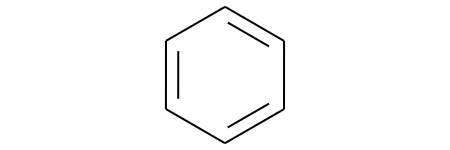

In [ ]:
mol = Chem.MolFromSmiles("c1ccccc1")
mol

Get SMILES of Imatinib (Gleevec)
*   From [ChEMBL](https://www.ebi.ac.uk/chembl/compound_report_card/CHEMBL941/)
*   From [Wikipedia](https://en.wikipedia.org/wiki/Imatinib)

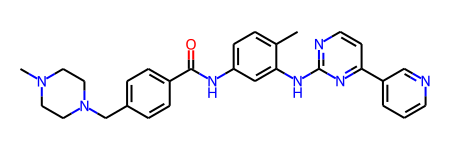

In [ ]:
glvc = Chem.MolFromSmiles("CN1CCN(Cc2ccc(cc2)C(=O)Nc3ccc(C)c(Nc4nccc(n4)c5cccnc5)c3)CC1")
glvc

Get SMILES of Tylenol
*   From [Wikipedia](https://en.wikipedia.org/wiki/Paracetamol)

In [ ]:
tylenol = Chem.MolFromSmiles("??")
tylenol

RDKit ERROR: [15:03:47] SMILES Parse Error: syntax error while parsing: ??
RDKit ERROR: [15:03:47] SMILES Parse Error: Failed parsing SMILES '??' for input: '??'


Read a set of molecules from an SD file

In [ ]:
!wget https://raw.githubusercontent.com/francisacquah466/DSW2021-Intro-to-Cheminformatics-ML/main/example_compounds.sdf

--2021-10-20 15:03:47--  https://raw.githubusercontent.com/francisacquah466/DSW2021-Intro-to-Cheminformatics-ML/main/example_compounds.sdf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 152641 (149K) [text/plain]
Saving to: ‘example_compounds.sdf’

example_compounds.s 100%[===================>] 149.06K  --.-KB/s    in 0.01s   

2021-10-20 15:03:48 (10.3 MB/s) - ‘example_compounds.sdf’ saved [152641/152641]



Check the first 10 lines of the sd file

In [ ]:
!head example_compounds.sdf

In [ ]:
mols = [x for x in Chem.SDMolSupplier("example_compounds.sdf")]

In [ ]:
mols

Draw these molecules as a grid

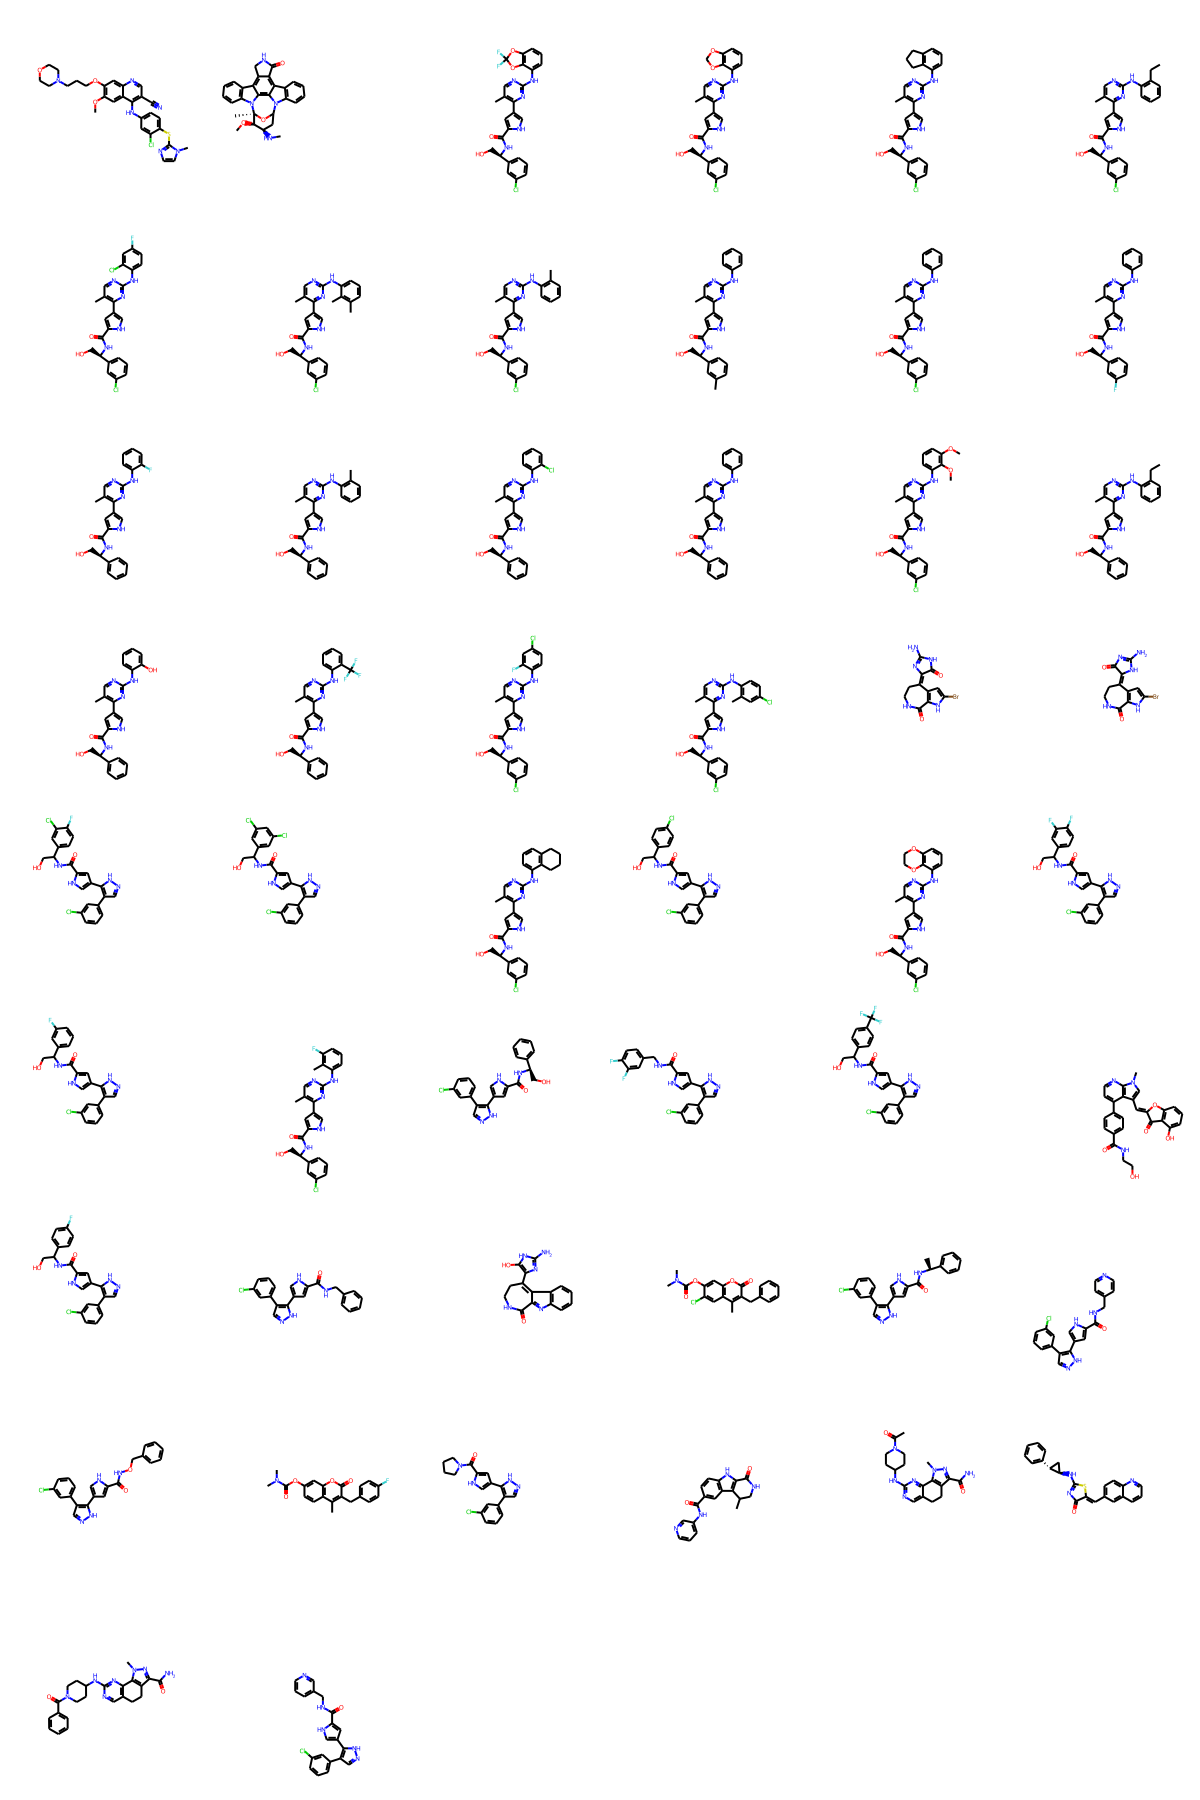

In [ ]:
Draw.MolsToGridImage(mols,molsPerRow=6,useSVG=True)

We can use the mols2grid library to display molecules in a grid

In [ ]:
mols2grid.display(mols)

In [ ]:
mols2grid.get_selection()

{}

We can also read an SD file into a Pandas dataframe.

In [ ]:
df = PandasTools.LoadSDF("example_compounds.sdf")

,ID,ROMol
0,168691 CHEMBL318804,
1,86358 CHEMBL162,
2,575087 CHEMBL576683,
3,575065 CHEMBL571484,
4,575047 CHEMBL568937,

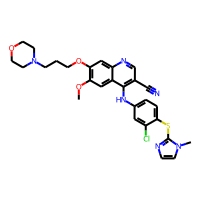
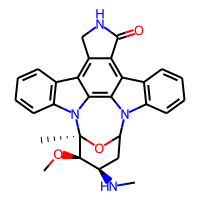
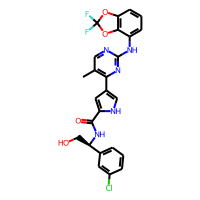
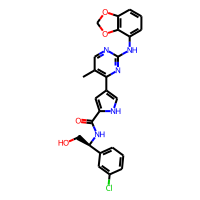
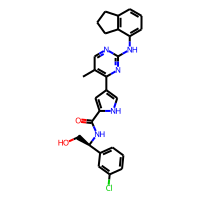

In [ ]:
df.head()

Let's add columns with molecular weight and LogP to the dataframe.

In [ ]:
from rdkit.Chem.Descriptors import MolWt
from rdkit.Chem.Crippen import MolLogP
df['MW'] = [MolWt(x) for x in df.ROMol]
df['LogP'] = [MolLogP(x) for x in df.ROMol]

,ID,ROMol,MW,LogP
0,168691 CHEMBL318804,,565.099,5.49788
1,86358 CHEMBL162,,466.541,4.35400
2,575087 CHEMBL576683,,527.915,4.96202
3,575065 CHEMBL571484,,491.935,4.36922
4,575047 CHEMBL568937,,487.991,5.12922

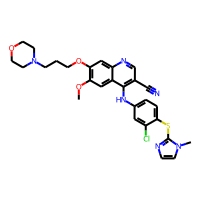
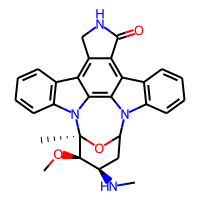
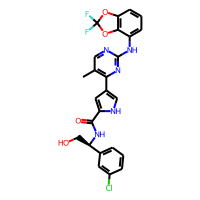
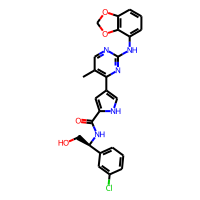
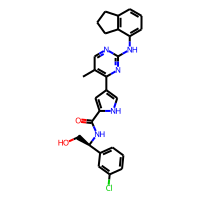

In [ ]:
df.head()

We can use a boxplot to examine the distribution of molecular weight within the dataframe.

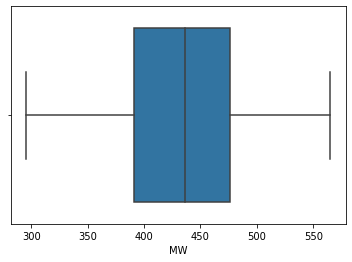

In [ ]:
ax = sns.boxplot(x=df.MW)

## 2. **Building a Simple Decision Tree**

A simple function to calculate molecular weight, LogP, number of aromatic rings, number of hydrogen bond donors and acceptors from a SMILES

In [ ]:
def calc_descriptors(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol:
        mw, logp, num_arom_rings, hbd, hba = [x(mol) for x in [MolWt, MolLogP, NumAromaticRings, NumHDonors, NumHAcceptors]]
        res = [mw, logp, num_arom_rings, hbd, hba]
    else:
        res = [None] * 5
    return res

# Read Delaney's solubility dataset

The full paper can be found: [ESOL:  Estimating Aqueous Solubility Directly from Molecular Structure](https://pubs.acs.org/doi/10.1021/ci034243x)

In [ ]:
!wget https://raw.githubusercontent.com/francisacquah466/DSW2021-Intro-to-Cheminformatics-ML/main/delaney.csv

--2021-10-20 15:03:49--  https://raw.githubusercontent.com/francisacquah466/DSW2021-Intro-to-Cheminformatics-ML/main/delaney.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 60034 (59K) [text/plain]
Saving to: ‘delaney.csv’

delaney.csv         100%[===================>]  58.63K  --.-KB/s    in 0.007s  

2021-10-20 15:03:50 (8.00 MB/s) - ‘delaney.csv’ saved [60034/60034]



In [ ]:
df = pd.read_csv("delaney.csv")

Get the dataframe column names

In [ ]:
df.head()

,Compound ID,measured log(solubility:mol/L),ESOL predicted log(solubility:mol/L),SMILES
0,"1,1,1,2-Tetrachloroethane",-2.18,-2.794,ClCC(Cl)(Cl)Cl
1,"1,1,1-Trichloroethane",-2.00,-2.232,CC(Cl)(Cl)Cl
2,"1,1,2,2-Tetrachloroethane",-1.74,-2.549,ClC(Cl)C(Cl)Cl
3,"1,1,2-Trichloroethane",-1.48,-1.961,ClCC(Cl)Cl
4,"1,1,2-Trichlorotrifluoroethane",-3.04,-3.077,FC(F)(Cl)C(F)(Cl)Cl


In [ ]:
df.columns

Index(['Compound ID', 'measured log(solubility:mol/L)',
       'ESOL predicted log(solubility:mol/L)', 'SMILES'],
      dtype='object')

Change the name of column 1 to "LogS"

In [ ]:
cols = list(df.columns)
cols[1] = 'LogS'
df.columns = cols

Add a new column "IsSol" to indicate whether a molecule's solubility is greater than 200uM


In [ ]:
df['IsSol'] = df.LogS > math.log10(200 * 1e-6)

In [ ]:
df.head()

,Compound ID,LogS,ESOL predicted log(solubility:mol/L),SMILES,IsSol
0,"1,1,1,2-Tetrachloroethane",-2.18,-2.794,ClCC(Cl)(Cl)Cl,True
1,"1,1,1-Trichloroethane",-2.00,-2.232,CC(Cl)(Cl)Cl,True
2,"1,1,2,2-Tetrachloroethane",-1.74,-2.549,ClC(Cl)C(Cl)Cl,True
3,"1,1,2-Trichloroethane",-1.48,-1.961,ClCC(Cl)Cl,True
4,"1,1,2-Trichlorotrifluoroethane",-3.04,-3.077,FC(F)(Cl)C(F)(Cl)Cl,True


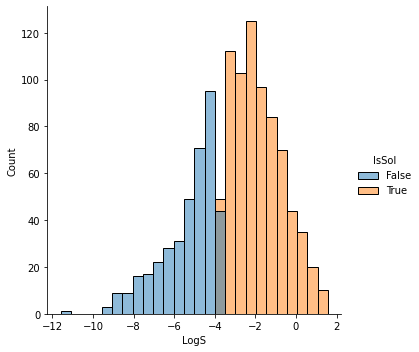

In [ ]:
sns.displot(x='LogS',hue="IsSol",data=df)

Add the descriptors to the dataframe. Note that all of the descriptors are going into one column called "desc".

In [ ]:
df['desc'] = df.SMILES.progress_apply(calc_descriptors)

100%|██████████| 1144/1144 [00:00<00:00, 2096.86it/s]


In [ ]:
df.head()

,Compound ID,LogS,ESOL predicted log(solubility:mol/L),SMILES,IsSol,desc
0,"1,1,1,2-Tetrachloroethane",-2.18,-2.794,ClCC(Cl)(Cl)Cl,True,"[167.85, 2.5954000000000006, 0, 0, 0]"
1,"1,1,1-Trichloroethane",-2.00,-2.232,CC(Cl)(Cl)Cl,True,"[133.405, 2.376500000000001, 0, 0, 0]"
2,"1,1,2,2-Tetrachloroethane",-1.74,-2.549,ClC(Cl)C(Cl)Cl,True,"[167.85, 2.5938, 0, 0, 0]"
3,"1,1,2-Trichloroethane",-1.48,-1.961,ClCC(Cl)Cl,True,"[133.405, 2.0289, 0, 0, 0]"
4,"1,1,2-Trichlorotrifluoroethane",-3.04,-3.077,FC(F)(Cl)C(F)(Cl)Cl,True,"[187.37500000000003, 2.9189, 0, 0, 0]"


Split the descriptors into their on own columns.

In [ ]:
desc_cols = ['MW','LogP','NumAromatic','HBD','HBA']
df[desc_cols] = df.desc.to_list()

In [ ]:
df.head()

,Compound ID,LogS,ESOL predicted log(solubility:mol/L),SMILES,IsSol,desc,MW,LogP,NumAromatic,HBD,HBA
0,"1,1,1,2-Tetrachloroethane",-2.18,-2.794,ClCC(Cl)(Cl)Cl,True,"[167.85, 2.5954000000000006, 0, 0, 0]",167.850,2.5954,0,0,0
1,"1,1,1-Trichloroethane",-2.00,-2.232,CC(Cl)(Cl)Cl,True,"[133.405, 2.376500000000001, 0, 0, 0]",133.405,2.3765,0,0,0
2,"1,1,2,2-Tetrachloroethane",-1.74,-2.549,ClC(Cl)C(Cl)Cl,True,"[167.85, 2.5938, 0, 0, 0]",167.850,2.5938,0,0,0
3,"1,1,2-Trichloroethane",-1.48,-1.961,ClCC(Cl)Cl,True,"[133.405, 2.0289, 0, 0, 0]",133.405,2.0289,0,0,0
4,"1,1,2-Trichlorotrifluoroethane",-3.04,-3.077,FC(F)(Cl)C(F)(Cl)Cl,True,"[187.37500000000003, 2.9189, 0, 0, 0]",187.375,2.9189,0,0,0


Split the data into training and test sets.

In [ ]:
train, test = train_test_split(df)

In [ ]:
train.shape, test.shape

((858, 11), (286, 11))

Look again at the X variables

In [ ]:
desc_cols

['MW', 'LogP', 'NumAromatic', 'HBD', 'HBA']

Split the training and test sets into X and y variables.

In [ ]:
train_X = train[desc_cols]
train_y = train.IsSol
test_X = test[desc_cols]
test_y = test.IsSol


Create and train a classifier

In [ ]:
cls = DecisionTreeClassifier(max_depth=2)
cls.fit(train_X,train_y)

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                       max_depth=2, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, presort='deprecated',
                       random_state=None, splitter='best')


Predict on the test set

In [ ]:
pred = cls.predict(test_X)
auc = roc_auc_score(test_y, pred)
print(f"ROC AUC = {auc:.2f}")


ROC AUC = 0.84


Plot a confusion matrix to show the classifier performance

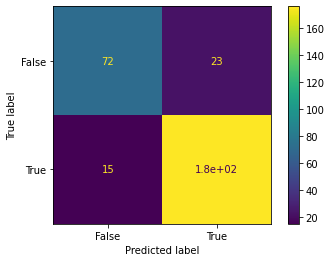

In [ ]:
plot_confusion_matrix(cls,test_X,test_y)

Plot an ROC cure to show the classifier performance

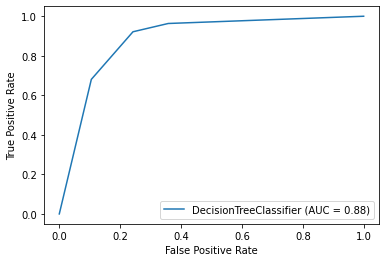

In [ ]:
plot_roc_curve(cls,test_X,test_y)

Use the default view from SciKit Learn to plot the decision tree

Use dtreeviz to plot the decision tree

findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
/usr/local/lib/python3.7/dist-packages/numpy/core/_asarray.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order)
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.


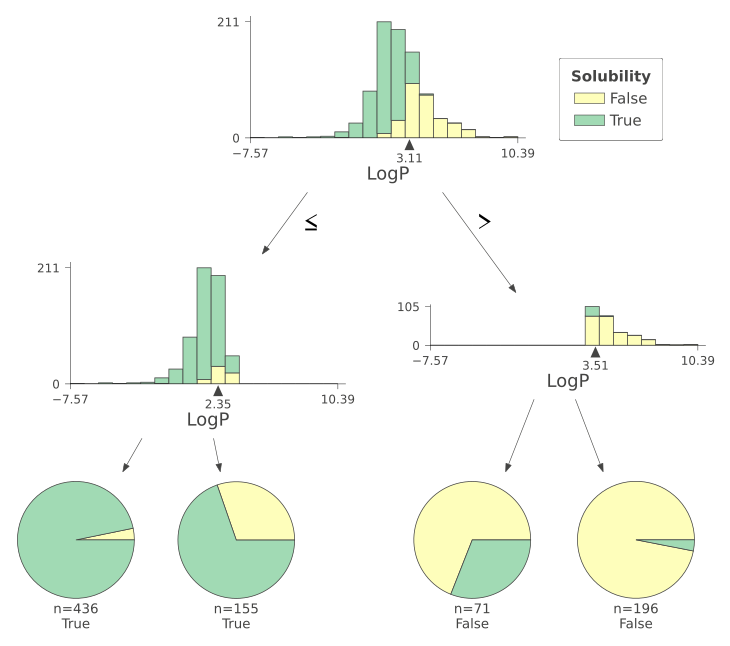

In [ ]:
viz = dtreeviz(cls, train_X, train_y, feature_names = desc_cols,
               target_name = "Solubility",class_names=["False","True"],scale=2)
viz

Can the classifier be used to classify new molecules as soluble or not??

In [ ]:
tylenol_sol = calc_descriptors('CC(=O)Nc1ccc(O)cc1')
tylenol_sol

[151.165, 1.3505999999999998, 1, 2, 2]

In [ ]:
print(cls.predict((tylenol_sol,)))
print(cls.predict_proba((tylenol_sol,)))

[ True]
[[0.03211009 0.96788991]]


In [ ]:
glvc_sol = calc_descriptors("CN1CCN(Cc2ccc(cc2)C(=O)Nc3ccc(C)c(Nc4nccc(n4)c5cccnc5)c3)CC1")
glvc_sol

[493.61500000000024, 4.590320000000004, 4, 2, 7]

In [ ]:
print(cls.predict((glvc_sol,)))
print(cls.predict_proba((glvc_sol,)))

[False]
[[0.96938776 0.03061224]]


## 3. **Clustering a library of molecules**

Clustering 1

In [ ]:
butina_cluster = ButinaCluster("rdkit")
df = pd.read_csv("delaney.csv")
df['Cluster'] = butina_cluster.cluster_smiles(df.SMILES,sim_cutoff=0.7)
cluster_rows = []
for k,v in df.groupby("Cluster"):
    cluster_rows.append([v.SMILES.values[0],k,len(v)])
cluster_df = pd.DataFrame(cluster_rows,columns=["SMILES","Cluster","Num"])
df.head()

Calculating Fingerprints:   0%|          | 0/1144 [00:00<?, ?it/s]

,Compound ID,measured log(solubility:mol/L),ESOL predicted log(solubility:mol/L),SMILES,Cluster
0,"1,1,1,2-Tetrachloroethane",-2.18,-2.794,ClCC(Cl)(Cl)Cl,50
1,"1,1,1-Trichloroethane",-2.00,-2.232,CC(Cl)(Cl)Cl,50
2,"1,1,2,2-Tetrachloroethane",-1.74,-2.549,ClC(Cl)C(Cl)Cl,209
3,"1,1,2-Trichloroethane",-1.48,-1.961,ClCC(Cl)Cl,50
4,"1,1,2-Trichlorotrifluoroethane",-3.04,-3.077,FC(F)(Cl)C(F)(Cl)Cl,639


In [ ]:
cols = list(df.columns)
cols[0] = 'Name'
df.columns = cols

In [ ]:
df.head()

,Name,measured log(solubility:mol/L),ESOL predicted log(solubility:mol/L),SMILES,Cluster
0,"1,1,1,2-Tetrachloroethane",-2.18,-2.794,ClCC(Cl)(Cl)Cl,50
1,"1,1,1-Trichloroethane",-2.00,-2.232,CC(Cl)(Cl)Cl,50
2,"1,1,2,2-Tetrachloroethane",-1.74,-2.549,ClC(Cl)C(Cl)Cl,209
3,"1,1,2-Trichloroethane",-1.48,-1.961,ClCC(Cl)Cl,50
4,"1,1,2-Trichlorotrifluoroethane",-3.04,-3.077,FC(F)(Cl)C(F)(Cl)Cl,639


In [ ]:
len(df)

1144

In [ ]:
cluster_df

,SMILES,Cluster,Num
0,Clc1c(Cl)c(Cl)c(c(Cl)c1Cl)c2c(Cl)c(Cl)c(Cl)c(C...,0,35
1,O=C1NC(=O)NC(=O)C1(CC)CC=C(C)C,1,24
2,Clc1cccc(Cl)c1c2c(Cl)cccc2Cl,2,1
3,CCCCCCCCCCO,3,16
4,Cc1cc(C)c2ccccc2c1,4,16
...,...,...,...
635,Brc1ccccc1Br,635,1
636,Oc1ccccc1O,636,1
637,C1CCc2ccccc2C1,637,1
638,CCOC(C)OCC,638,1


In [ ]:
mols2grid.display(cluster_df,subset=["img","Num"])

In [ ]:
display_cluster_members(df,mols2grid.get_selection().keys(),True)

'Nothing selected'

# **References**

1. [Pat Walters Github](https://github.com/PatWalters/chem_tutorial)
2. [Data Professor YouTube](https://www.youtube.com/c/DataProfessor)
3. [Deep Learning for the Life Sciences](https://www.oreilly.com/library/view/deep-learning-for/9781492039822/)
4.[ESOL:  Estimating Aqueous Solubility Directly from Molecular Structure](https://pubs.acs.org/doi/10.1021/ci034243x)